In [6]:
import pandas as pd
import numpy as np
from datetime import datetime
from dateutil.relativedelta import relativedelta
import matplotlib.pyplot as plt 
import itertools
import os 

In [ ]:

def simulate_amortization_cpr(payment_freq, maturity_years, N_0, K_rate, cpr, start_date, apply_cpr=True):
    """
    Inputs: Mortgage Payment Frequency (12 = monthly), Maturity Years (e.g. 2), Initial Principal, Mortgage Rate (e.g. 0.05),
             CPR (e.g. 0.05), Start Date (e.g. 01-01-2026), Apply CPR (Set at TRUE)

    Outputs: List of Residual Debt,
             List of Time in Years (hardcoded as steps in 6 months for visualisation),
             List of Actual Dates (e.g. 01-01-2026, 01-07-20206,...)
    """
    total_periods = int(maturity_years * payment_freq)
    
    # Standard Annuity Formula for Initial Payment (PMT)
    discount_factor = (1.0 + K_rate) ** (-total_periods)
    pmt = (K_rate * N_0) / (1.0 - discount_factor)

    n_list = []
    time_list = []
    date_list = []

    # Initial State 
    N_prev = N_0
    n_list.append(N_prev)
    time_list.append(0.0)
    date_list.append(start_date)
    current_date = start_date

    for i in range(1, total_periods + 1):
        
        # 1. Standard Amortization Components
        interest_payment = K_rate * N_prev
        principal_payment = pmt - interest_payment

        # 2. Outstanding Balance & Prepayment
        if apply_cpr and i < total_periods:
            standard_balance = N_prev - principal_payment
            prepayment_amount = cpr * standard_balance
            N_curr = standard_balance - prepayment_amount
        else:
            N_curr = N_prev - principal_payment

        # 3. Recalculate Annuity
        if apply_cpr and i < total_periods:
            remaining_periods = total_periods - i
            discount_factor = (1.0 + K_rate) ** (-remaining_periods)
            pmt = (K_rate * N_curr) / (1.0 - discount_factor)

        # 4. Step Time Forward (Hardcoded to 6 months for semi-annual grid)
        delta_time = relativedelta(months=6)
        current_date = current_date + delta_time

        # Store Results
        n_list.append(max(0, N_curr)) # Prevent negative balances
        time_list.append(i * 0.5)
        date_list.append(current_date)

        # Update for next iteration
        N_prev = N_curr

    return n_list, time_list, date_list

In [10]:
path[1]

[0.0,
 0.5,
 1.0,
 1.5,
 2.0,
 2.5,
 3.0,
 3.5,
 4.0,
 4.5,
 5.0,
 5.5,
 6.0,
 6.5,
 7.0,
 7.5,
 8.0,
 8.5,
 9.0,
 9.5,
 10.0]

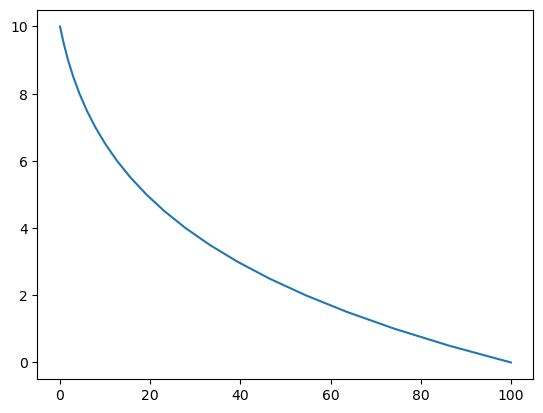

In [11]:
path = simulate_amortization_cpr(2, 10, 100, 0.02, 0.1, pd.to_datetime('01-01-2025'), apply_cpr=True)

plt.plot(path[0], path[1])


In [ ]:
def simulate_amortization_cpr(payment_freq, maturity_years, N_0, K_rate, cpr, start_date, apply_cpr=True):
    return n_list, time_list, date_list

In [18]:
def build_amortization_bands(maturity_years, CPR, N0, K, ref_date, pay_yy=2, base_pp = 0.01):
    """

    Inputs: Maturity Years (e.g. 2), CPR (e.g. 0.05), Initial Principal,
            Mortgage Rate (e.g. 0.05), Start Date (e.g. 01-01-2026), Mortgage Payment Frequency (Set at 6 months),
            Baseline CPR (Set at 0.01)

    Outputs: List of Actual Dates (e.g. 01-01-2026, 01-07-20206,...)
             List of Residual Debt under baseline CPR
             List of Residual Debt under inputted CPR
             List of Time in Years (hardcoded as steps in 6 months for visualisation),
             
    Returns the Baseline expected path and the Stressed tail path.
    """

    upper_n, time_list, dates_upper = simulate_amortization_cpr(
        pay_yy, maturity_years, N0, K, base_pp, ref_date, True
    )
    lower_n, _, dates_lower = simulate_amortization_cpr(
        pay_yy, maturity_years, N0, K, CPR, ref_date, True
    )

    return dates_upper, upper_n, lower_n, time_list

In [20]:
dates, upper, lower, times = build_amortization_bands(5, 0.05, 100, 0.05, pd.to_datetime('01-01-2025'), pay_yy=2, base_pp = 0.01)

In [22]:
build_constant_prepay_ptf(dates, upper, lower, 0.05, p_min=0.01)

,OPTION_EXPIRY,SWAP_TENOR,STRIKE,NOTIONAL,TYPE
0,2025-07-01,4.503765,0.05,3.681982,RECEIVER
1,2026-01-01,4.000000,0.05,2.850079,RECEIVER
2,2026-07-01,3.504449,0.05,2.031805,RECEIVER
3,2027-01-01,3.000684,0.05,1.225378,RECEIVER
4,2027-07-01,2.505133,0.05,0.429064,RECEIVER


In [26]:
simulate_amortization_cpr(2, 10, 100, 0.02, 0.15, pd.to_datetime('01-01-2025'), apply_cpr=True)[0]

[100,
 81.50167895935033,
 66.2433827732045,
 53.67722591249891,
 43.34573595704757,
 34.86719700203461,
 27.92333713894721,
 22.24898903692296,
 17.623410871849575,
 13.863003996205345,
 10.815205219475033,
 8.353366566835101,
 6.372464908763744,
 4.785508756918221,
 3.5205305211151434,
 2.518070226343818,
 1.729071611096531,
 1.1131241029486663,
 0.6369947609652715,
 0.2734031969093521,
 6.106226635438361e-16]

In [27]:
build_hybrid_ptf(dates, upper, lower,simulate_amortization_cpr(2, 10, 100, 0.02, 0.15, pd.to_datetime('01-01-2025'), apply_cpr=True)[0], 0.05, p_min=0.01)

,OPTION_EXPIRY,SWAP_TENOR,STRIKE,NOTIONAL,TYPE
0,2025-07-01,4.503765,0.05,3.681982,RECEIVER_ATM
1,2025-07-01,4.503765,0.03,5.945386,RECEIVER_OTM
2,2026-01-01,4.000000,0.05,2.850079,RECEIVER_ATM
3,2026-01-01,4.000000,0.03,3.411344,RECEIVER_OTM
4,2026-07-01,3.504449,0.05,2.031805,RECEIVER_ATM
5,2026-07-01,3.504449,0.03,1.366879,RECEIVER_OTM
6,2027-01-01,3.000684,0.05,1.225378,RECEIVER_ATM
7,2027-07-01,2.505133,0.05,0.429064,RECEIVER_ATM


In [23]:
# ============================================================
# 4) Hybrid Portfolio Builder
# ============================================================

def build_hybrid_ptf(dates, N_min, N_exp, N_max, K, p_min=0.01):
    portfolio = []
    
    # from basel 3 (200 bps shock)
    K_OTM = K - 0.02 

    for i in range(1, len(dates)):
        
        delta_N_baseline_curr = N_min[i] - N_exp[i]
        delta_N_baseline_prev = N_min[i-1] - N_exp[i-1]
        
        delta_N_tail_curr = N_exp[i] - N_max[i]
        delta_N_tail_prev = N_exp[i-1] - N_max[i-1]

        # incremental strips (omega)
        omega_ATM = delta_N_baseline_curr - delta_N_baseline_prev * (1 - p_min)
        omega_OTM = delta_N_tail_curr - delta_N_tail_prev * (1 - p_min)

        tenor_years = (dates[-1] - dates[i]).days / 365.25

        #Again only consider actual notionals 

        # atm layer
        if omega_ATM > 0.01:
            portfolio.append({
                'OPTION_EXPIRY': dates[i],
                'SWAP_TENOR': tenor_years,
                'STRIKE': K,
                'NOTIONAL': omega_ATM,
                'TYPE': 'RECEIVER_ATM'
            })
            
        # otm layer
        if omega_OTM > 0.01:
            portfolio.append({
                'OPTION_EXPIRY': dates[i],
                'SWAP_TENOR': tenor_years,
                'STRIKE': K_OTM,
                'NOTIONAL': omega_OTM,
                'TYPE': 'RECEIVER_OTM'
            })
            
    return pd.DataFrame(portfolio)

In [28]:
# ============================================================
# 3) Portfolio Builder - Constant Prepayment Hedge
# ============================================================

def build_constant_prepay_ptf(dates, expected_n, lower_n, K, p_min=0.01):
    portfolio = []

    for i in range(1, len(dates)):
        # Calculate the gaps for the current and previous periods
        delta_curr = expected_n[i] - lower_n[i]
        delta_prev = expected_n[i-1] - lower_n[i-1]
        
        # Calculate the incremental notional (omega_i)
        notional = delta_curr - delta_prev * (1 - p_min)

        # Only add to portfolio if bigger than 0.01 = 0.01 % of N_0 
        if notional > 0.01: 
            tenor_years = (dates[-1] - dates[i]).days / 365.25
            row = {
                'OPTION_EXPIRY': dates[i],
                'SWAP_TENOR': tenor_years,
                'STRIKE': K,
                'NOTIONAL': notional,
                'TYPE': 'RECEIVER_ATM'
            }
            portfolio.append(row) 
            
    return pd.DataFrame(portfolio)